In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    precision_recall_fscore_support,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [29]:
olid_train = pd.read_csv("data/olid-train-small.csv")
olid_test = pd.read_csv("data/olid-test.csv")
hasoc_train = pd.read_csv("data/hasoc-train.csv")

print("OLID train:", olid_train.shape)
print("OLID test:", olid_test.shape)
print("HASOC train:", hasoc_train.shape)

print("\nOLID train labels:")
print(olid_train["labels"].value_counts())

print("\nHASOC train labels:")
print(hasoc_train["labels"].value_counts())

OLID train: (5852, 3)
OLID test: (860, 3)
HASOC train: (5852, 3)

OLID train labels:
labels
0    3591
1    2261
Name: count, dtype: int64

HASOC train labels:
labels
0    3591
1    2261
Name: count, dtype: int64


In [30]:
def run_logistic_regression(train_df, test_df, experiment_name):
    
    model = Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ])

    X_train = train_df["text"]
    y_train = train_df["labels"]

    X_test = test_df["text"]
    y_test = test_df["labels"]

    # Train and predict
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    # Per-class metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test,
        predictions,
        labels=[0, 1]
    )

    # Macro metrics
    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            y_test,
            predictions,
            average="macro"
        )
    )

    accuracy = accuracy_score(y_test, predictions)

    # Confusion matrix
    cm = confusion_matrix(y_test, predictions, labels=[0, 1])

    # Save predictions
    results = test_df.copy()
    results["prediction"] = predictions
    results["correct"] = results["labels"] == results["prediction"]

    metrics = {
        "Experiment": experiment_name,
        "NOT Precision": precision[0],
        "NOT Recall": recall[0],
        "NOT F1": f1[0],
        "OFF Precision": precision[1],
        "OFF Recall": recall[1],
        "OFF F1": f1[1],
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Accuracy": accuracy
    }

    return model, results, metrics, cm

In [31]:
lr_olid, olid_results, olid_metrics, cm_olid = run_logistic_regression(
    olid_train,
    olid_test,
    "In-domain: OLID → OLID"
)

lr_hasoc, hasoc_results, hasoc_metrics, cm_hasoc = run_logistic_regression(
    hasoc_train,
    olid_test,
    "Cross-domain: HASOC → OLID"
)

print("Both experiments complete.")

Both experiments complete.


In [32]:
comparison = pd.DataFrame([
    olid_metrics,
    hasoc_metrics
])

comparison.round(4)

,Experiment,NOT Precision,NOT Recall,NOT F1,OFF Precision,OFF Recall,OFF F1,Macro Precision,Macro Recall,Macro F1,Accuracy
0,In-domain: OLID → OLID,0.8025,0.9500,0.8700,0.7540,0.3958,0.5191,0.7782,0.6729,0.6946,0.7953
1,Cross-domain: HASOC → OLID,0.7805,0.7742,0.7773,0.4286,0.4375,0.4330,0.6045,0.6058,0.6052,0.6802


In [33]:
macro_f1_drop = (
    olid_metrics["Macro F1"]
    - hasoc_metrics["Macro F1"]
)

relative_drop = (
    macro_f1_drop / olid_metrics["Macro F1"]
) * 100

print(f"In-domain Macro F1:   {olid_metrics['Macro F1']:.4f}")
print(f"Cross-domain Macro F1: {hasoc_metrics['Macro F1']:.4f}")
print(f"Absolute drop:         {macro_f1_drop:.4f}")
print(f"Relative drop:         {relative_drop:.2f}%")

In-domain Macro F1:   0.6946
Cross-domain Macro F1: 0.6052
Absolute drop:         0.0894
Relative drop:         12.87%


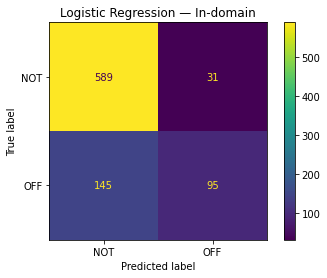

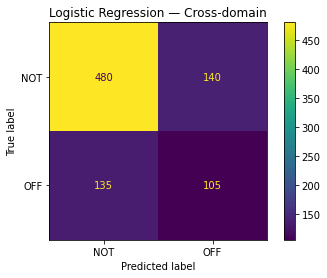

In [34]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_olid,
    display_labels=["NOT", "OFF"]
)

disp.plot()
plt.title("Logistic Regression — In-domain")
plt.show()

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_hasoc,
    display_labels=["NOT", "OFF"]
)

disp.plot()
plt.title("Logistic Regression — Cross-domain")
plt.show()

In [35]:
olid_results.to_csv(
    "logistic_regression_olid_predictions.csv",
    index=False
)

hasoc_results.to_csv(
    "logistic_regression_hasoc_predictions.csv",
    index=False
)

print("Prediction files saved.")

Prediction files saved.


In [36]:
def error_counts(results):
    false_positives = results[
        (results["labels"] == 0) &
        (results["prediction"] == 1)
    ]

    false_negatives = results[
        (results["labels"] == 1) &
        (results["prediction"] == 0)
    ]

    return false_positives, false_negatives


olid_fp, olid_fn = error_counts(olid_results)
hasoc_fp, hasoc_fn = error_counts(hasoc_results)

print("IN-DOMAIN")
print("False positives:", len(olid_fp))
print("False negatives:", len(olid_fn))

print("\nCROSS-DOMAIN")
print("False positives:", len(hasoc_fp))
print("False negatives:", len(hasoc_fn))

IN-DOMAIN
False positives: 31
False negatives: 145

CROSS-DOMAIN
False positives: 140
False negatives: 135


In [37]:
print("Cross-domain false positives:")
for text in hasoc_fp["text"].head(5):
    print("-", text)

print("\nCross-domain false negatives:")
for text in hasoc_fn["text"].head(5):
    print("-", text)

Cross-domain false positives:
- #Watching #Boomer getting the news that she is still up for parole always makes me smile. #Wentworth Finale...@USER is such a treasure. URL
- #RAP is a form of ART! Used to express yourself freely. It does not gv the green light or excuse the behavior of acting like an animal! She is not in the streets of the BX where violence is a way of living. Elevate yourself boo and get on @USER level for longevity! #QUEEN👑
- #Dayspromo week of September 17th #days #dool  A coma does things to a gal . Sami: You are going to be ok. Hattie: No thanks to you.  Get her out of here. Before she finishes me off.  Hattie pretends to be Marlena.  The look on Kayla face is priceless. URL
- #Kavanaugh so a wild claim from 36 years ago of groping has evolved into A Rape A Violent Sexual Event by Move URL a Soros based Org. that supports BLM Antifa etc. Unbeievable!
- #HIAC  Damn Matt Hardy and Randy Orton put on one hell in a cell match!! Woooo!!! I hope he is okay!!

Cross-dom